# Notebook 05 — Model Evaluation & Explainability

## Goal

Evaluate the trained `ClinicalDecisionModel` and explain its predictions using:

1. **Full Evaluation** — Accuracy, Weighted F1, Confusion Matrix across all splits
2. **SHAP Analysis** — Feature importance for the `DecisionHead` inputs
3. **Unified Representation Analysis** — PCA / t-SNE of the 256-d fusion embeddings
4. **Similar Patient Retrieval** — Cosine similarity search in representation space
5. **Per-Patient Explainability** — Waterfall plots for individual predictions
6. **Calibration** — Reliability diagram (confidence vs actual accuracy)

All plots are saved under `reports/figures/fusion/` for use in the final report and UI.

---

### Inputs (produced by previous notebooks)

| File | Source |
|---|---|
| `models/fusion/best_decision_model.pth` | NB04 |
| `models/fusion/clinical_scaler.pkl` | NB04 |
| `models/fusion/severity_thresholds.json` | NB04 |
| `reports/fusion/representations/{split}_unified_repr.npy` | NB04 |
| `reports/fusion/representations/{split}_repr_metadata.csv` | NB04 |
| `datasets/processed/fusion/{encoder}/{split}_fusion.npz` | NB01 |
| `datasets/processed/clinical_features/{split}_clinical_features.csv` | NB03 |

---

## 1. Imports & Setup

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.calibration import calibration_curve

import shap

print("All imports OK")


All imports OK


## 2. Configuration

In [2]:
TEXT_ENCODER = "biobert"   # match NB04 — change to "clinicalbert" if needed

# ── Input paths ───────────────────────────────────────────────────────────────
FUSION_DIR    = Path(f"/kaggle/input/datasets/mariammohamed1095/models/datasets/processed/fusion/{TEXT_ENCODER}")
CLINICAL_DIR  = Path("/kaggle/input/datasets/mariammohamed1095/modelsss/datasets/processed/clinical_features")
MODEL_DIR     = Path("/kaggle/input/models/mariammohamed1095/mo/pytorch/default/1/models/fusion")
REPR_DIR      = Path("/kaggle/input/models/mariammohamed1095/mo/pytorch/default/1/reports/fusion/representations")

# ── Output paths ─────────────────────────────────────────────────────────────
FIGURE_DIR    = Path("reports/figures/fusion")
RESULT_DIR    = Path("reports/results/fusion")

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE    = 32
RISK_NAMES    = ["Low Risk", "Medium Risk", "High Risk"]
RISK_COLORS   = ["#2a78d6", "#eda100", "#e63946"]

print("Device :", DEVICE)
print("Figures:", FIGURE_DIR)
print("Results:", RESULT_DIR)


Device : cuda
Figures: reports/figures/fusion
Results: reports/results/fusion


## 3. Rebuild Model Architecture & Load Checkpoint

In [3]:
# ── Architecture (identical to NB04) ─────────────────────────────────────────

class ImageProjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(256, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.20),
        )
    def forward(self, x): return self.projection(x)


class TextProjection(nn.Module):
    def __init__(self):
        super().__init__()
        self.projection = nn.Sequential(
            nn.Linear(768, 512), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(0.20),
            nn.Linear(256, 128), nn.LayerNorm(128),
        )
    def forward(self, x): return self.projection(x)


class FusionBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.fusion = nn.Sequential(
            nn.Linear(256, 256), nn.GELU(), nn.Dropout(0.30),
            nn.Linear(256, 256), nn.LayerNorm(256),
        )
    def forward(self, image, text):
        return self.fusion(torch.cat([image, text], dim=1))


class FusionEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_projection = ImageProjection()
        self.text_projection  = TextProjection()
        self.fusion_block     = FusionBlock()
    def forward(self, image, text):
        return self.fusion_block(
            self.image_projection(image),
            self.text_projection(text),
        )


class DecisionHead(nn.Module):
    def __init__(self, fusion_dim=256, clinical_dim=13, hidden_dim=128, num_classes=3):
        super().__init__()
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim + clinical_dim, hidden_dim),
            nn.ReLU(), nn.Dropout(0.30),
            nn.Linear(hidden_dim, 64),
            nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )
    def forward(self, fusion_repr, clinical):
        return self.classifier(torch.cat([fusion_repr, clinical], dim=1))


class ClinicalDecisionModel(nn.Module):
    def __init__(self, clinical_dim):
        super().__init__()
        self.fusion_encoder = FusionEncoder()
        self.decision_head  = DecisionHead(
            fusion_dim=256, clinical_dim=clinical_dim,
            hidden_dim=128, num_classes=3,
        )
    def forward(self, image, text, clinical):
        unified_repr = self.fusion_encoder(image, text)
        logits       = self.decision_head(unified_repr, clinical)
        return logits, unified_repr


In [4]:
# ── Load checkpoint ───────────────────────────────────────────────────────────
ckpt = torch.load(MODEL_DIR / "best_decision_model.pth", map_location=DEVICE, weights_only=False)

CLINICAL_COLUMNS = ckpt["clinical_cols"]
CLINICAL_DIM     = ckpt["clinical_dim"]

model = ClinicalDecisionModel(clinical_dim=CLINICAL_DIM).to(DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

print(f"Checkpoint epoch   : {ckpt['epoch']}")
print(f"Best val accuracy  : {ckpt['val_acc']:.4f}")
print(f"Clinical dim       : {CLINICAL_DIM}")
print(f"Clinical columns   : {CLINICAL_COLUMNS}")


Checkpoint epoch   : 13
Best val accuracy  : 0.8750
Clinical dim       : 13
Clinical columns   : ['wt_volume', 'tc_volume', 'et_volume', 'frontal', 'temporal', 'parietal', 'occipital', 'left', 'right', 'bilateral', 'word_count', 'sentence_count', 'lobe_count']


## 4. Load Data

In [5]:
scaler     = joblib.load(MODEL_DIR / "clinical_scaler.pkl")
thresholds = json.loads((MODEL_DIR / "severity_thresholds.json").read_text())

WT_THRESHOLD = thresholds["WT_THRESHOLD"]
TC_THRESHOLD = thresholds["TC_THRESHOLD"]
ET_THRESHOLD = thresholds["ET_THRESHOLD"]

print("Thresholds:", thresholds)


Thresholds: {'WT_THRESHOLD': 138460.0, 'TC_THRESHOLD': 58843.0, 'ET_THRESHOLD': 30143.0}


In [6]:
def _safe(row, col):
    return int(row[col]) if col in row.index else 0

def compute_clinical_score(df):
    scores = []
    for _, row in df.iterrows():
        score = 0
        if row["wt_volume"] >= WT_THRESHOLD: score += 2
        if row["et_volume"] >= ET_THRESHOLD: score += 2
        if row["tc_volume"] >= TC_THRESHOLD: score += 1
        if row.get("lobe_count", 0) >= 3:    score += 1
        if row.get("bilateral", 0) == 1:     score += 1
        scores.append(score)
    return scores

def risk_label(score):
    if score <= 1: return 0
    if score <= 3: return 1
    return 2

def load_split(split):
    fusion   = np.load(FUSION_DIR / f"{split}_fusion.npz")
    clinical = pd.read_csv(CLINICAL_DIR / f"{split}_clinical_features.csv")
    clinical["severity_score"] = compute_clinical_score(clinical)
    clinical["risk_label"]     = clinical["severity_score"].apply(risk_label)
    clinical[CLINICAL_COLUMNS] = scaler.transform(clinical[CLINICAL_COLUMNS])
    return {
        "image":    fusion["image_features"],
        "text":     fusion["text_features"],
        "clinical": clinical,
    }

train      = load_split("train")
validation = load_split("validation")
test       = load_split("test")

for name, data in {"Train": train, "Validation": validation, "Test": test}.items():
    vc = data["clinical"]["risk_label"].value_counts().sort_index()
    print(f"{name:12}  Low={vc.get(0,0)}  Medium={vc.get(1,0)}  High={vc.get(2,0)}")


Train         Low=154  Medium=60  High=43
Validation    Low=31  Medium=9  High=16
Test          Low=34  Medium=15  High=7


In [7]:
class FusionDataset(Dataset):
    def __init__(self, image_features, text_features, clinical_features, labels):
        self.image    = image_features.astype(np.float32)
        self.text     = text_features.astype(np.float32)
        self.clinical = clinical_features.astype(np.float32)
        self.labels   = labels.astype(np.int64)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return {
            "image":    torch.tensor(self.image[idx]),
            "text":     torch.tensor(self.text[idx]),
            "clinical": torch.tensor(self.clinical[idx]),
            "label":    torch.tensor(self.labels[idx]),
        }

def make_loader(data, shuffle=False):
    ds = FusionDataset(
        data["image"], data["text"],
        data["clinical"][CLINICAL_COLUMNS].values,
        data["clinical"]["risk_label"].values,
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle)

train_loader      = make_loader(train)
validation_loader = make_loader(validation)
test_loader       = make_loader(test)
print("DataLoaders ready.")


DataLoaders ready.


## 5. Full Evaluation

Accuracy, Weighted F1, and Classification Report across all three splits.


In [8]:
def evaluate_loader(loader):
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for batch in loader:
            logits, _ = model(
                batch["image"].to(DEVICE),
                batch["text"].to(DEVICE),
                batch["clinical"].to(DEVICE),
            )
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1).tolist())
            all_labels.extend(batch["label"].tolist())
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

results = {}
for name, loader in [("train", train_loader), ("validation", validation_loader), ("test", test_loader)]:
    labels, preds, probs = evaluate_loader(loader)
    results[name] = {"labels": labels, "preds": preds, "probs": probs}
    acc = accuracy_score(labels, preds)
    f1  = f1_score(labels, preds, average="weighted")
    print(f"{'='*55}")
    print(f"{name.upper():12}  Accuracy: {acc:.4f}  Weighted-F1: {f1:.4f}")
    print(classification_report(labels, preds, target_names=RISK_NAMES, digits=4))


TRAIN         Accuracy: 0.8016  Weighted-F1: 0.7938
              precision    recall  f1-score   support

    Low Risk     0.8773    0.9286    0.9022       154
 Medium Risk     0.6042    0.4833    0.5370        60
   High Risk     0.7391    0.7907    0.7640        43

    accuracy                         0.8016       257
   macro avg     0.7402    0.7342    0.7344       257
weighted avg     0.7904    0.8016    0.7938       257

VALIDATION    Accuracy: 0.8750  Weighted-F1: 0.8721
              precision    recall  f1-score   support

    Low Risk     0.9355    0.9355    0.9355        31
 Medium Risk     0.6250    0.5556    0.5882         9
   High Risk     0.8824    0.9375    0.9091        16

    accuracy                         0.8750        56
   macro avg     0.8143    0.8095    0.8109        56
weighted avg     0.8704    0.8750    0.8721        56

TEST          Accuracy: 0.8036  Weighted-F1: 0.8062
              precision    recall  f1-score   support

    Low Risk     0.9394    

### 5.1 Confusion Matrices

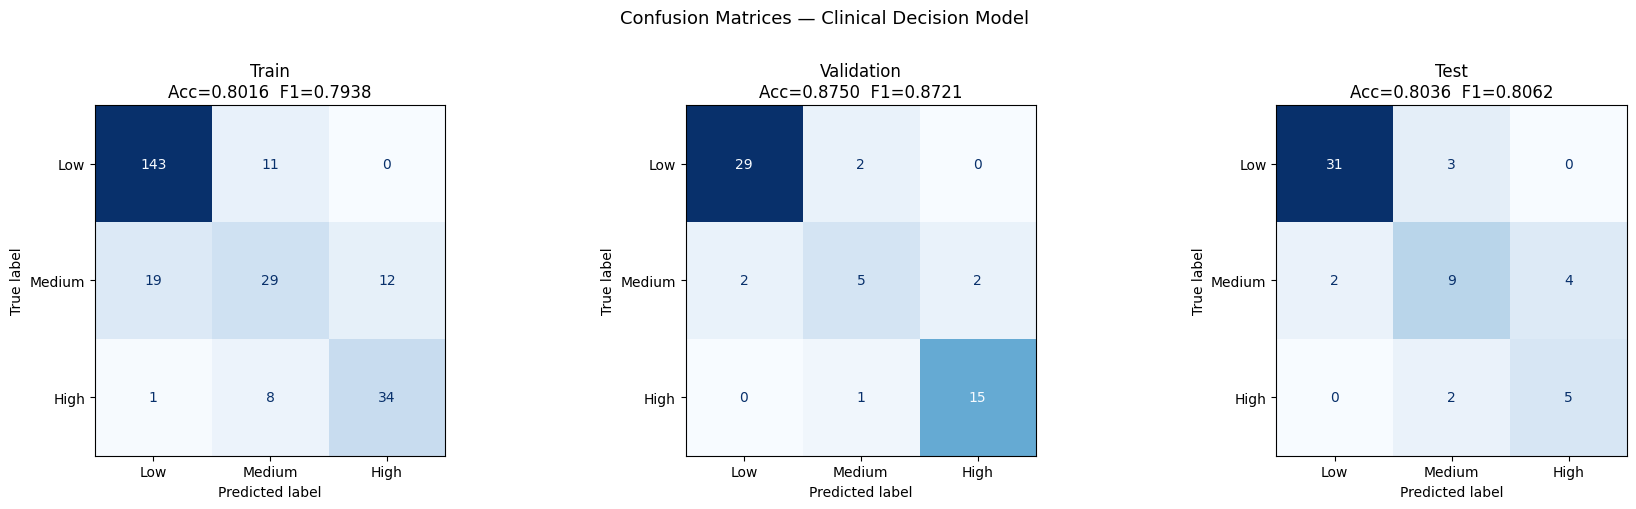

Saved → confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, res) in zip(axes, results.items()):
    cm = confusion_matrix(res["labels"], res["preds"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    acc = accuracy_score(res["labels"], res["preds"])
    f1  = f1_score(res["labels"], res["preds"], average="weighted")
    ax.set_title(f"{split_name.capitalize()}\nAcc={acc:.4f}  F1={f1:.4f}", fontsize=12)
    ax.grid(False)

plt.suptitle("Confusion Matrices — Clinical Decision Model", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confusion_matrices.png")


### 5.2 Training History

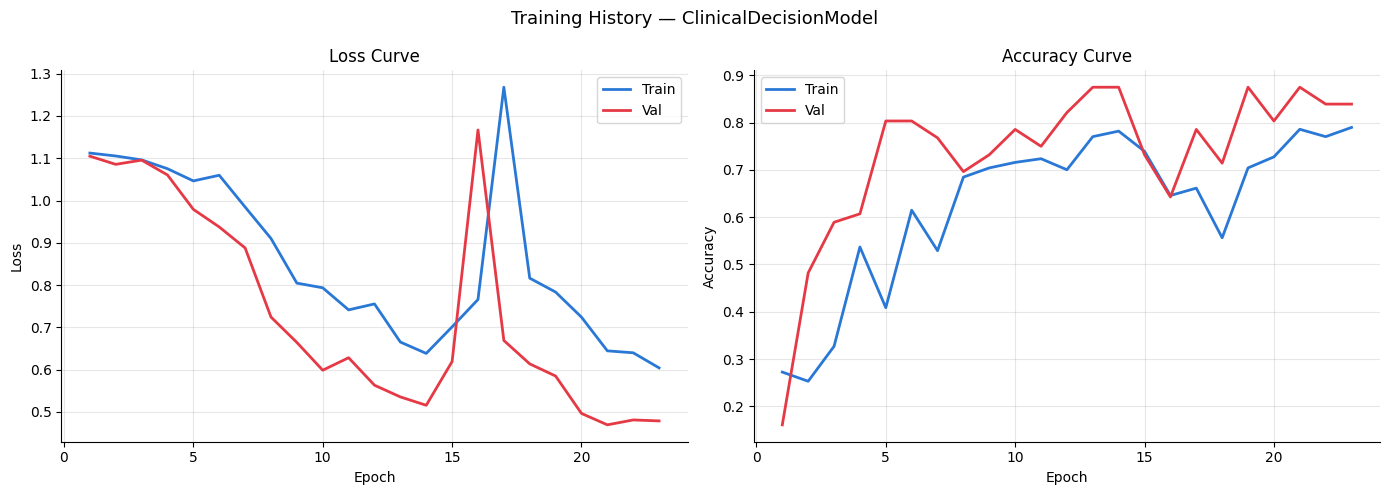

Saved → training_history.png


In [10]:
history_df = pd.read_csv(MODEL_DIR / "training_history.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Train", color="#2a78d6", lw=2)
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="Val",   color="#e63946", lw=2)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].spines[["top","right"]].set_visible(False)

axes[1].plot(history_df["epoch"], history_df["train_acc"], label="Train", color="#2a78d6", lw=2)
axes[1].plot(history_df["epoch"], history_df["val_acc"],   label="Val",   color="#e63946", lw=2)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].spines[["top","right"]].set_visible(False)

plt.suptitle("Training History — ClinicalDecisionModel", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → training_history.png")


## 6. Calibration — Reliability Diagram

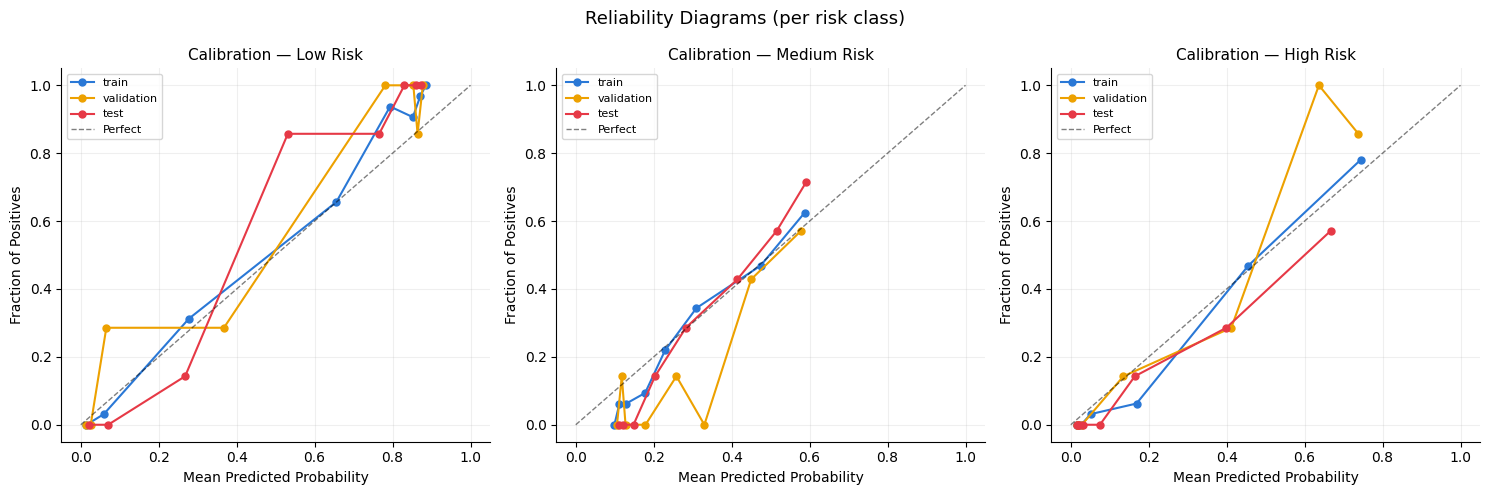

Saved → calibration.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cls_idx, cls_name in zip(axes, range(3), RISK_NAMES):
    for split_name, color in [("train","#2a78d6"), ("validation","#eda100"), ("test","#e63946")]:
        res = results[split_name]
        binary_labels = (res["labels"] == cls_idx).astype(int)
        prob_cls = res["probs"][:, cls_idx]
        if binary_labels.sum() == 0:
            continue
        fraction_pos, mean_pred = calibration_curve(binary_labels, prob_cls, n_bins=8, strategy="quantile")
        ax.plot(mean_pred, fraction_pos, "o-", color=color, label=split_name, lw=1.5, ms=5)

    ax.plot([0,1],[0,1], "k--", lw=1, alpha=0.5, label="Perfect")
    ax.set_xlabel("Mean Predicted Probability"); ax.set_ylabel("Fraction of Positives")
    ax.set_title(f"Calibration — {cls_name}", fontsize=11)
    ax.legend(fontsize=8); ax.grid(alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Reliability Diagrams (per risk class)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → calibration.png")


## 7. SHAP Explainability

SHAP is applied to the **DecisionHead** — the classifier that takes the
256-d fusion representation + clinical features as input.

We use `shap.GradientExplainer` which is compatible with PyTorch and
efficient for MLP-style models.


In [12]:
# Build the input matrix that DecisionHead sees:
# concatenation of [unified_repr (256) | clinical (N)]

def collect_decision_inputs(loader):
    all_repr, all_clin, all_labels = [], [], []
    with torch.no_grad():
        for batch in loader:
            _, unified_repr = model(
                batch["image"].to(DEVICE),
                batch["text"].to(DEVICE),
                batch["clinical"].to(DEVICE),
            )
            all_repr.append(unified_repr.cpu())
            all_clin.append(batch["clinical"])
            all_labels.append(batch["label"])
    return (
        torch.cat(all_repr),
        torch.cat(all_clin),
        torch.cat(all_labels),
    )

train_repr, train_clin, train_lbl = collect_decision_inputs(train_loader)
val_repr,   val_clin,   val_lbl   = collect_decision_inputs(validation_loader)
test_repr,  test_clin,  test_lbl  = collect_decision_inputs(test_loader)

# Full input to DecisionHead
train_dh_input = torch.cat([train_repr, train_clin], dim=1)
test_dh_input  = torch.cat([test_repr,  test_clin],  dim=1)

print("DecisionHead input shape (train):", train_dh_input.shape)
print("Feature count:", train_dh_input.shape[1],
      f"  (256 repr + {CLINICAL_DIM} clinical)")


DecisionHead input shape (train): torch.Size([257, 269])
Feature count: 269   (256 repr + 13 clinical)


In [13]:
# SHAP feature names
repr_feature_names  = [f"repr_{i}" for i in range(256)]
shap_feature_names  = repr_feature_names + CLINICAL_COLUMNS

# Wrap DecisionHead for SHAP
class DecisionHeadWrapper(nn.Module):
    def __init__(self, head):
        super().__init__()
        self.head = head
    def forward(self, x):
        # x: (B, 256 + clinical_dim)
        fusion_part   = x[:, :256]
        clinical_part = x[:, 256:]
        return self.head(fusion_part, clinical_part)

dh_wrapper = DecisionHeadWrapper(model.decision_head).to(DEVICE)
dh_wrapper.eval()

# Background sample (200 random train examples)
torch.manual_seed(42)
bg_idx = torch.randperm(train_dh_input.shape[0])[:200]
background = train_dh_input[bg_idx].to(DEVICE)

explainer   = shap.GradientExplainer(dh_wrapper, background)

# Explain test set (all examples)
test_input_device = test_dh_input.to(DEVICE)
shap_values       = explainer.shap_values(test_input_device)  # list of 3 arrays (N, F)

print("SHAP values computed.")
print("Shape per class:", shap_values[0].shape)


SHAP values computed.
Shape per class: (269, 3)


In [14]:
print(type(shap_values))

if isinstance(shap_values, list):

    for i, s in enumerate(shap_values):
        print(i, s.shape)

else:

    print(shap_values.shape)

<class 'numpy.ndarray'>
(56, 269, 3)


### 7.1 Global Feature Importance (Top 20 Clinical + Repr Features)

13
13


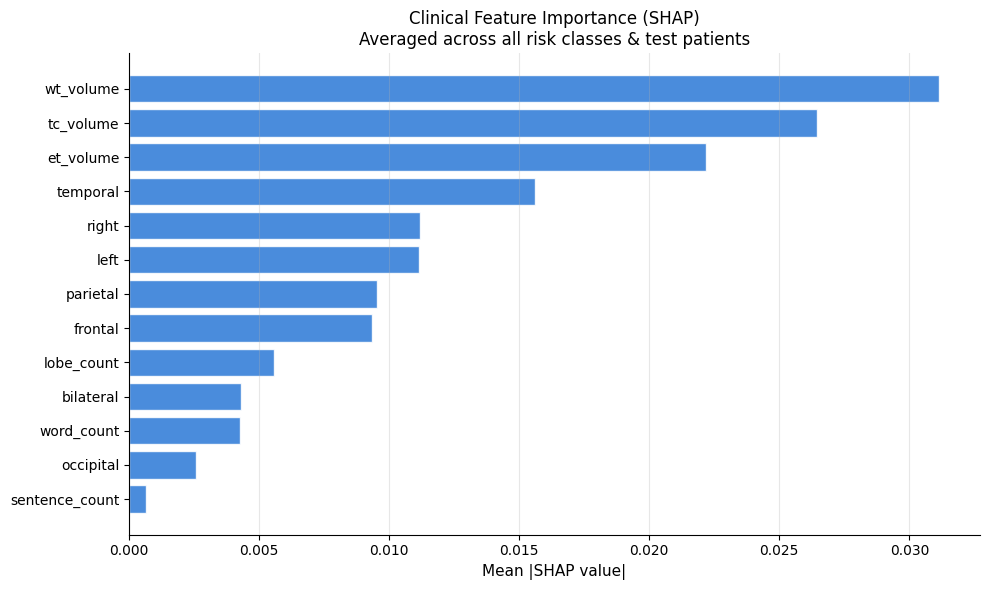

Saved → shap_clinical_importance.png


In [15]:
# Mean absolute SHAP across classes and samples
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))

clinical_shap = mean_abs_shap[-CLINICAL_DIM:]

clinical_feat_names = CLINICAL_COLUMNS

print(len(clinical_feat_names))
print(len(clinical_shap))

shap_df = pd.DataFrame({

    "feature": clinical_feat_names,

    "importance": clinical_shap,

})

shap_df = shap_df.sort_values(

    "importance",

    ascending=False,

)
clinical_feat_names = CLINICAL_COLUMNS

shap_df = pd.DataFrame({
    "feature":    clinical_feat_names,
    "importance": clinical_shap,
}).sort_values("importance", ascending=False)

shap_df.to_csv(RESULT_DIR / "shap_clinical_importance.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    shap_df["feature"][::-1],
    shap_df["importance"][::-1],
    color="#2a78d6", alpha=0.85, edgecolor="white",
)
ax.set_xlabel("Mean |SHAP value|", fontsize=11)
ax.set_title("Clinical Feature Importance (SHAP)\nAveraged across all risk classes & test patients", fontsize=12)
ax.grid(axis="x", alpha=0.3)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_clinical_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_clinical_importance.png")


### 7.2 SHAP Beeswarm — Clinical Features per Risk Class

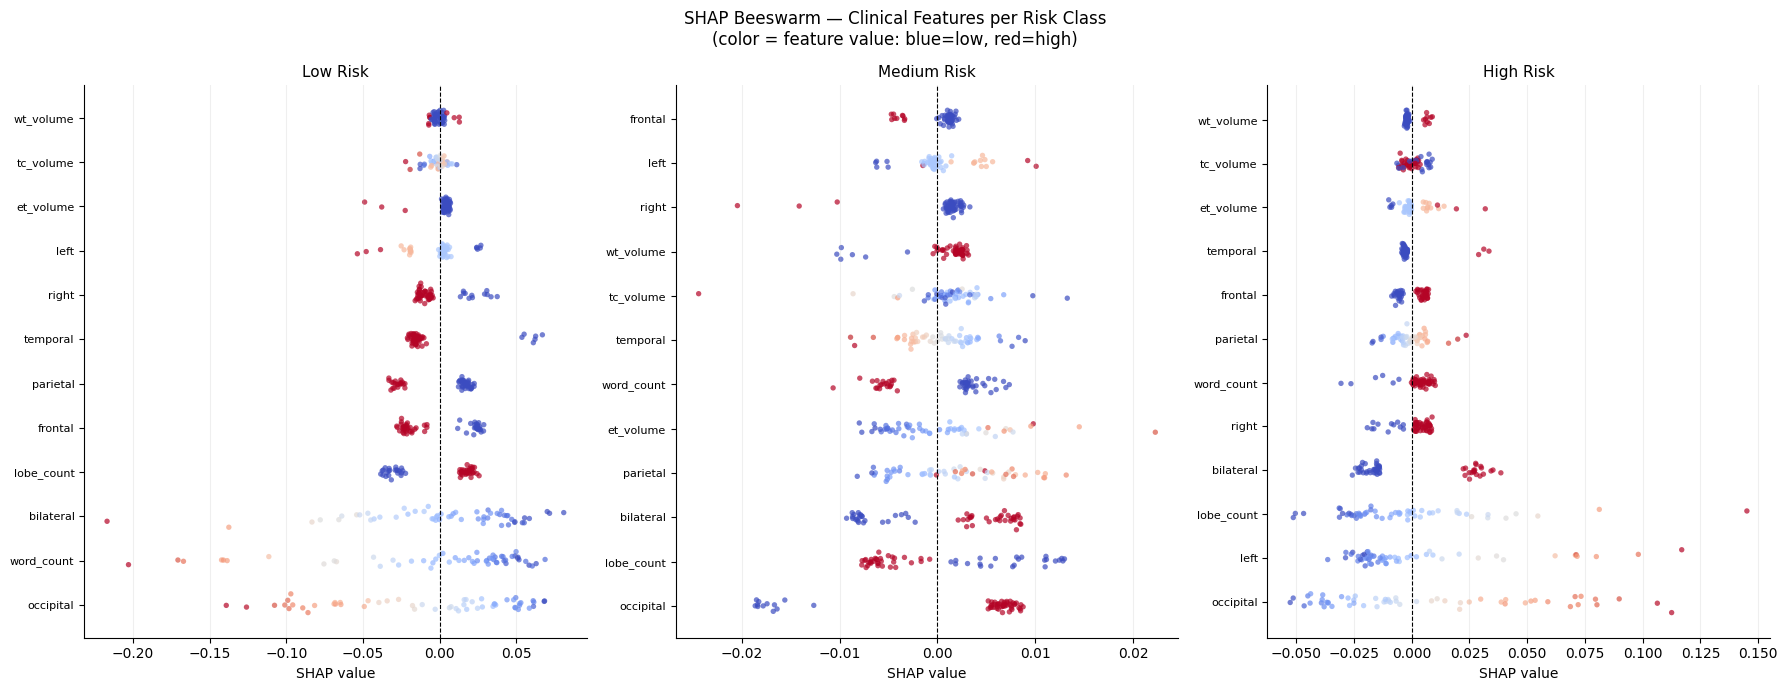

Saved → shap_beeswarm.png


In [16]:
class_labels_str = ["Low Risk", "Medium Risk", "High Risk"]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for cls_idx, (ax, cls_name) in enumerate(zip(axes, class_labels_str)):
    # Clinical SHAP values for this class
    sv = shap_values[:,256:,cls_idx]   # (N, clinical_dim)

    # Sort features by mean |SHAP|
    order = np.argsort(np.abs(sv).mean(axis=0))[::-1][:12]   # top 12
    sv_top    = sv[:, order]
    feat_top  = [CLINICAL_COLUMNS[i] for i in order]
    feat_vals = test_clin.numpy()[:, order]

    for j in range(sv_top.shape[1]):
        y_jitter = np.random.normal(j, 0.08, size=sv_top.shape[0])
        ax.scatter(
            sv_top[:, j], y_jitter,
            c=feat_vals[:, j], cmap="coolwarm",
            s=15, alpha=0.7, linewidths=0,
        )

    ax.set_yticks(range(len(feat_top)))
    ax.set_yticklabels(feat_top[::-1], fontsize=8)
    ax.axvline(0, color="black", lw=0.8, linestyle="--")
    ax.set_xlabel("SHAP value", fontsize=10)
    ax.set_title(f"{cls_name}", fontsize=11)
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("SHAP Beeswarm — Clinical Features per Risk Class\n(color = feature value: blue=low, red=high)", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_beeswarm.png")


### 7.3 Waterfall Plot — Single Patient Explainability

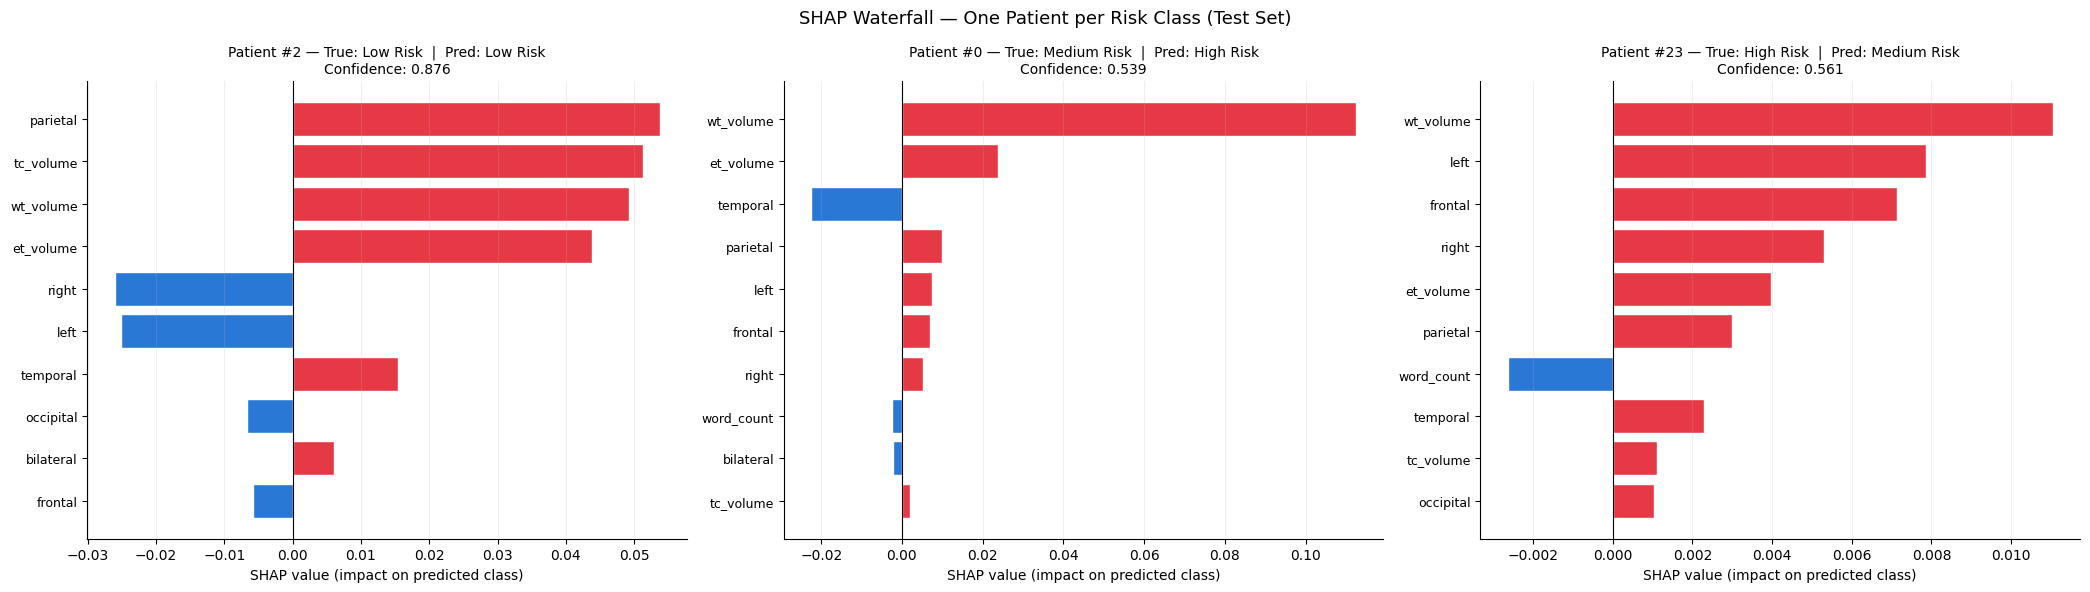

Saved → shap_waterfall_examples.png


In [17]:
def plot_waterfall(patient_idx, split="test", ax=None):
    """
    Show SHAP waterfall for one patient — top clinical features only.
    """
    sv_all  = shap_values        # list of 3: each (N, F)
    ci      = test_clin.numpy()  # (N, clinical_dim)

    labels, preds, probs = results[split]["labels"], results[split]["preds"], results[split]["probs"]
    true_cls = labels[patient_idx]
    pred_cls = preds[patient_idx]

    # SHAP for predicted class, clinical features only
    sv_patient = shap_values[patient_idx,256:,pred_cls]   # (clinical_dim,)

    order = np.argsort(np.abs(sv_patient))[::-1][:10]
    feat_names_top = [CLINICAL_COLUMNS[i] for i in order]
    shap_top       = sv_patient[order]

    colors = ["#e63946" if v > 0 else "#2a78d6" for v in shap_top]

    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 5))

    ax.barh(range(len(shap_top)), shap_top[::-1], color=colors[::-1], edgecolor="white")
    ax.set_yticks(range(len(feat_names_top)))
    ax.set_yticklabels(feat_names_top[::-1], fontsize=9)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("SHAP value (impact on predicted class)", fontsize=10)
    ax.set_title(
        f"Patient #{patient_idx} — True: {RISK_NAMES[true_cls]}  |  Pred: {RISK_NAMES[pred_cls]}\n"
        f"Confidence: {probs[patient_idx][pred_cls]:.3f}",
        fontsize=10,
    )
    ax.grid(axis="x", alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

    if standalone:
        plt.tight_layout()
        path = FIGURE_DIR / f"waterfall_patient_{patient_idx}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved → {path.name}")


# Plot waterfall for 3 interesting patients: Low, Medium, High
test_labels = results["test"]["labels"]
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
shown = {}
for idx in range(len(test_labels)):
    cls = test_labels[idx]
    if cls not in shown:
        shown[cls] = idx
    if len(shown) == 3:
        break

for ax, (cls, idx) in zip(axes, sorted(shown.items())):
    plot_waterfall(idx, split="test", ax=ax)

plt.suptitle("SHAP Waterfall — One Patient per Risk Class (Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "shap_waterfall_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → shap_waterfall_examples.png")


## 8. Unified Representation Analysis

PCA and t-SNE of the 256-d fusion representations produced by `FusionEncoder`.
These were saved by NB04 (`{split}_unified_repr.npy`).


In [18]:
repr_data = {}
for split in ["train", "validation", "test"]:
    repr_data[split] = {
        "repr": np.load(REPR_DIR / f"{split}_unified_repr.npy"),
        "meta": pd.read_csv(REPR_DIR / f"{split}_repr_metadata.csv"),
    }
    print(f"{split:12}  repr shape: {repr_data[split]['repr'].shape}")


train         repr shape: (257, 256)
validation    repr shape: (56, 256)
test          repr shape: (56, 256)


In [19]:
# Combine all splits for global embedding analysis
all_repr   = np.concatenate([repr_data[s]["repr"] for s in ["train","validation","test"]])
all_labels = np.concatenate([repr_data[s]["meta"]["risk_label"].values for s in ["train","validation","test"]])
all_splits = np.concatenate([
    np.full(len(repr_data[s]["repr"]), i)
    for i, s in enumerate(["train","validation","test"])
])

scaler_repr = StandardScaler()
all_repr_sc = scaler_repr.fit_transform(all_repr)

pca = PCA(n_components=2, random_state=42)
repr_pca = pca.fit_transform(all_repr_sc)

tsne = TSNE(n_components=2, perplexity=15, random_state=42, max_iter=1000)
repr_tsne = tsne.fit_transform(all_repr_sc)

print(f"PCA explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.3f}")
print(f"t-SNE done. Shape: {repr_tsne.shape}")


PCA explained variance (2 PCs): 0.899
t-SNE done. Shape: (369, 2)


### 8.1 PCA & t-SNE — Colored by Risk Label

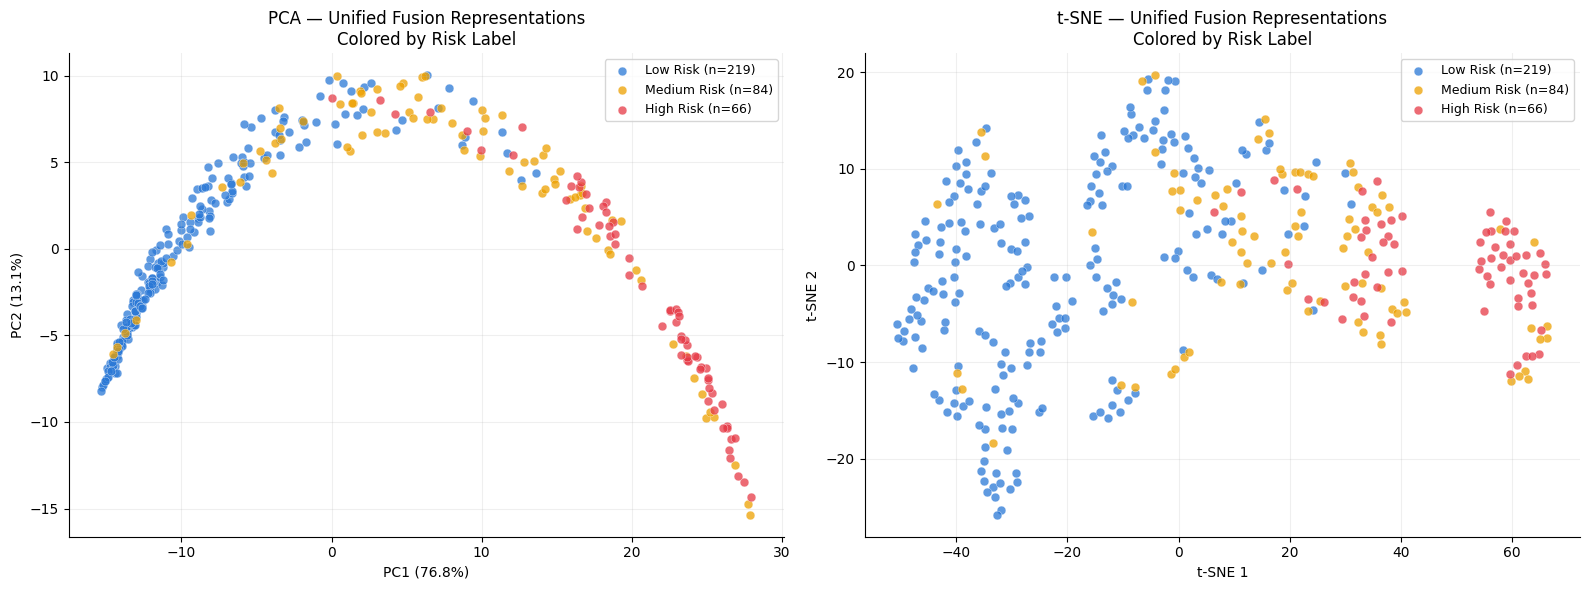

Saved → repr_pca_tsne_risk.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, coords, title in zip(
    axes,
    [repr_pca, repr_tsne],
    ["PCA", "t-SNE"],
):
    for cls_idx, (cls_name, color) in enumerate(zip(RISK_NAMES, RISK_COLORS)):
        mask = all_labels == cls_idx
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=color, s=40, alpha=0.75, edgecolors="white", linewidths=0.3,
            label=f"{cls_name} (n={mask.sum()})",
        )
    ax.set_title(f"{title} — Unified Fusion Representations\nColored by Risk Label", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)
    if title == "PCA":
        ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
        ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    else:
        ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig(FIGURE_DIR / "repr_pca_tsne_risk.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → repr_pca_tsne_risk.png")


### 8.2 PCA — Colored by Split

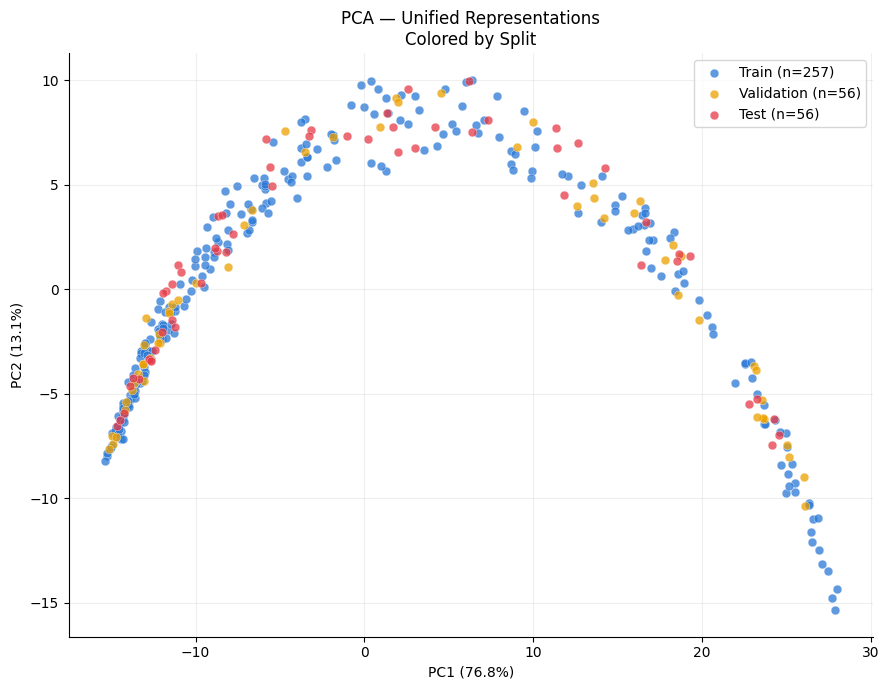

Saved → repr_pca_splits.png


In [21]:
split_colors = ["#2a78d6", "#eda100", "#e63946"]
split_names  = ["Train", "Validation", "Test"]

fig, ax = plt.subplots(figsize=(9, 7))
for split_idx, (sname, scolor) in enumerate(zip(split_names, split_colors)):
    mask = all_splits == split_idx
    ax.scatter(
        repr_pca[mask, 0], repr_pca[mask, 1],
        c=scolor, s=40, alpha=0.75, edgecolors="white",
        linewidths=0.3, label=f"{sname} (n={mask.sum()})",
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA — Unified Representations\nColored by Split", fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "repr_pca_splits.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → repr_pca_splits.png")


## 9. Similar Patient Retrieval

Given a query patient, find the most similar patients in the 256-d
fusion representation space using cosine similarity.
This can power "find similar cases" features in the clinical UI.


In [22]:
def find_similar_patients(
    query_patient_id: str,
    repr_matrix:      np.ndarray,
    patient_ids:      list,
    top_k:            int = 5,
) -> pd.DataFrame:
    """
    Return the top_k most similar patients to a query patient
    based on cosine similarity of their fusion representations.
    """
    if query_patient_id not in patient_ids:
        raise ValueError(f"{query_patient_id!r} not found.")

    q_idx   = patient_ids.index(query_patient_id)
    q_feat  = repr_matrix[q_idx].reshape(1, -1)
    sims    = cosine_similarity(q_feat, repr_matrix)[0]
    sims[q_idx] = -1   # exclude self

    top_idx = np.argsort(sims)[::-1][:top_k]
    return pd.DataFrame({
        "rank":               range(1, top_k + 1),
        "patient_id":         [patient_ids[i] for i in top_idx],
        "cosine_similarity":  [round(float(sims[i]), 4) for i in top_idx],
    })


# Use validation repr for retrieval demo
val_repr_arr = repr_data["validation"]["repr"]
val_meta     = repr_data["validation"]["meta"]
val_pids     = val_meta["patient_id"].tolist()

query_id = val_pids[0]
similar  = find_similar_patients(query_id, val_repr_arr, val_pids)

print(f"Query patient : {query_id}")
print(similar.to_string(index=False))
similar.to_csv(RESULT_DIR / "similar_patients_demo.csv", index=False)


Query patient : BraTS20_Training_009
 rank           patient_id  cosine_similarity
    1 BraTS20_Training_020             0.9965
    2 BraTS20_Training_047             0.9938
    3 BraTS20_Training_270             0.9895
    4 BraTS20_Training_293             0.9892
    5 BraTS20_Training_140             0.9874


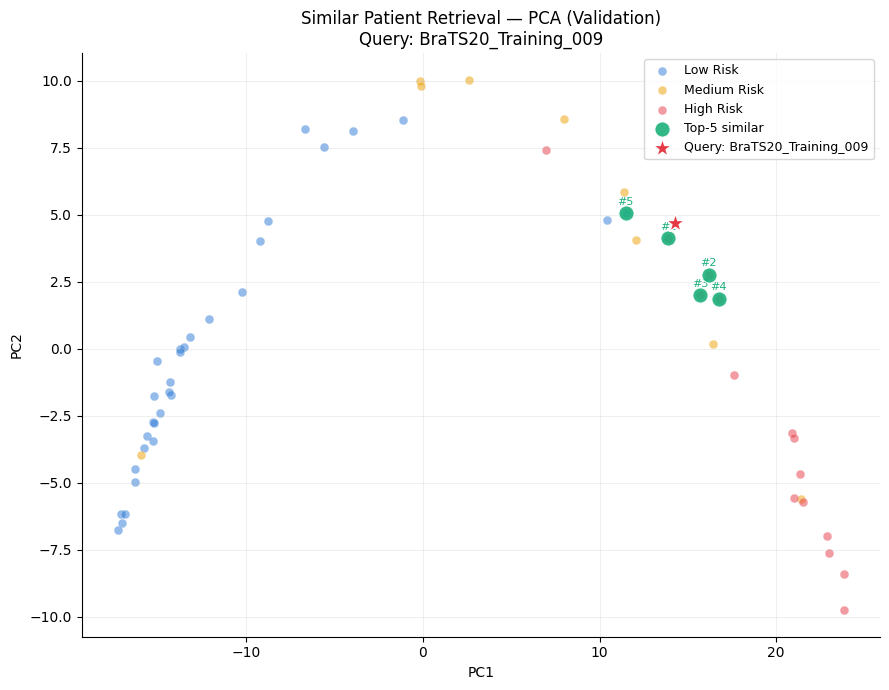

Saved → similar_patient_retrieval.png


In [23]:
# Visualize retrieval in PCA space (validation only)
val_pca_sc = scaler_repr.transform(val_repr_arr)
val_pca    = PCA(n_components=2, random_state=42).fit_transform(val_pca_sc)

q_idx    = val_pids.index(query_id)
top5_idx = [val_pids.index(pid) for pid in similar["patient_id"]]
val_risk = val_meta["risk_label"].values

fig, ax = plt.subplots(figsize=(9, 7))

for cls_idx, (cls_name, color) in enumerate(zip(RISK_NAMES, RISK_COLORS)):
    mask = val_risk == cls_idx
    ax.scatter(val_pca[mask, 0], val_pca[mask, 1],
               c=color, s=40, alpha=0.5, edgecolors="white", linewidths=0.3, label=cls_name)

ax.scatter(val_pca[top5_idx, 0], val_pca[top5_idx, 1],
           c="#1baf7a", s=120, alpha=0.9, edgecolors="white", linewidths=0.8,
           label="Top-5 similar", zorder=4)
for rank, idx in enumerate(top5_idx, 1):
    ax.annotate(f"#{rank}", (val_pca[idx, 0], val_pca[idx, 1]),
                xytext=(0, 6), textcoords="offset points",
                fontsize=8, ha="center", color="#1baf7a")

ax.scatter(val_pca[q_idx, 0], val_pca[q_idx, 1],
           c="#e63946", s=200, zorder=5, marker="*",
           edgecolors="white", linewidths=1, label=f"Query: {query_id}")

ax.set_title(f"Similar Patient Retrieval — PCA (Validation)\nQuery: {query_id}", fontsize=12)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=9); ax.grid(alpha=0.2)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "similar_patient_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → similar_patient_retrieval.png")


## 10. Confidence Distribution & Error Analysis

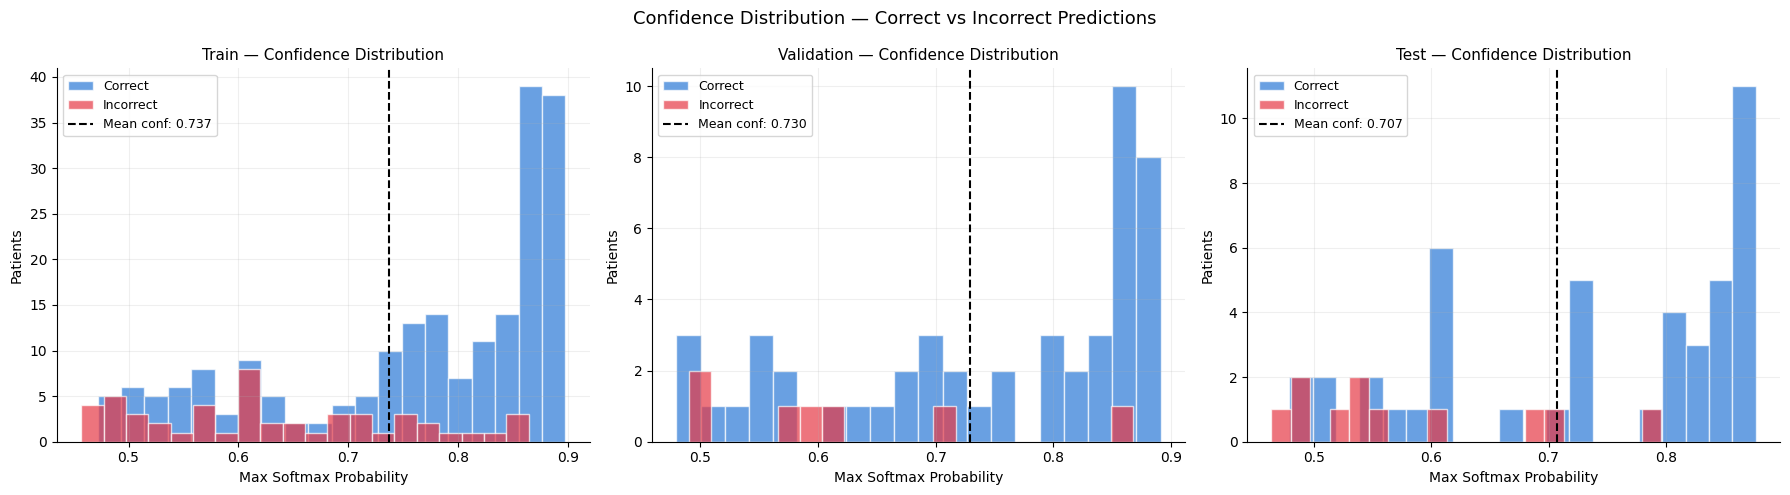

Saved → confidence_distribution.png


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (split_name, res) in zip(axes, results.items()):
    probs      = res["probs"]
    labels     = res["labels"]
    preds      = res["preds"]
    confidence = probs.max(axis=1)
    correct    = (labels == preds)

    ax.hist(confidence[correct],  bins=20, alpha=0.7, color="#2a78d6", label="Correct",   edgecolor="white")
    ax.hist(confidence[~correct], bins=20, alpha=0.7, color="#e63946", label="Incorrect", edgecolor="white")
    ax.axvline(confidence.mean(), color="black", lw=1.5, linestyle="--",
               label=f"Mean conf: {confidence.mean():.3f}")
    ax.set_xlabel("Max Softmax Probability")
    ax.set_ylabel("Patients")
    ax.set_title(f"{split_name.capitalize()} — Confidence Distribution", fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.2)
    ax.spines[["top","right"]].set_visible(False)

plt.suptitle("Confidence Distribution — Correct vs Incorrect Predictions", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "confidence_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → confidence_distribution.png")


## 11. Summary

In [25]:
print("=" * 65)
print("Notebook 05 — Evaluation & Explainability Complete")
print("=" * 65)

print("\nMetrics:")
for split_name, res in results.items():
    acc = accuracy_score(res["labels"], res["preds"])
    f1  = f1_score(res["labels"], res["preds"], average="weighted")
    print(f"  {split_name:12}  Accuracy: {acc:.4f}  Weighted-F1: {f1:.4f}")

print("\nFigures saved:")
for fig_file in sorted(FIGURE_DIR.glob("*.png")):
    print(f"  {fig_file}")

print("\nResults saved:")
for csv_file in sorted(RESULT_DIR.glob("*.csv")):
    print(f"  {csv_file}")


Notebook 05 — Evaluation & Explainability Complete

Metrics:
  train         Accuracy: 0.8016  Weighted-F1: 0.7938
  validation    Accuracy: 0.8750  Weighted-F1: 0.8721
  test          Accuracy: 0.8036  Weighted-F1: 0.8062

Figures saved:
  reports/figures/fusion/calibration.png
  reports/figures/fusion/confidence_distribution.png
  reports/figures/fusion/confusion_matrices.png
  reports/figures/fusion/repr_pca_splits.png
  reports/figures/fusion/repr_pca_tsne_risk.png
  reports/figures/fusion/shap_beeswarm.png
  reports/figures/fusion/shap_clinical_importance.png
  reports/figures/fusion/shap_waterfall_examples.png
  reports/figures/fusion/similar_patient_retrieval.png
  reports/figures/fusion/training_history.png

Results saved:
  reports/results/fusion/shap_clinical_importance.csv
  reports/results/fusion/similar_patients_demo.csv
